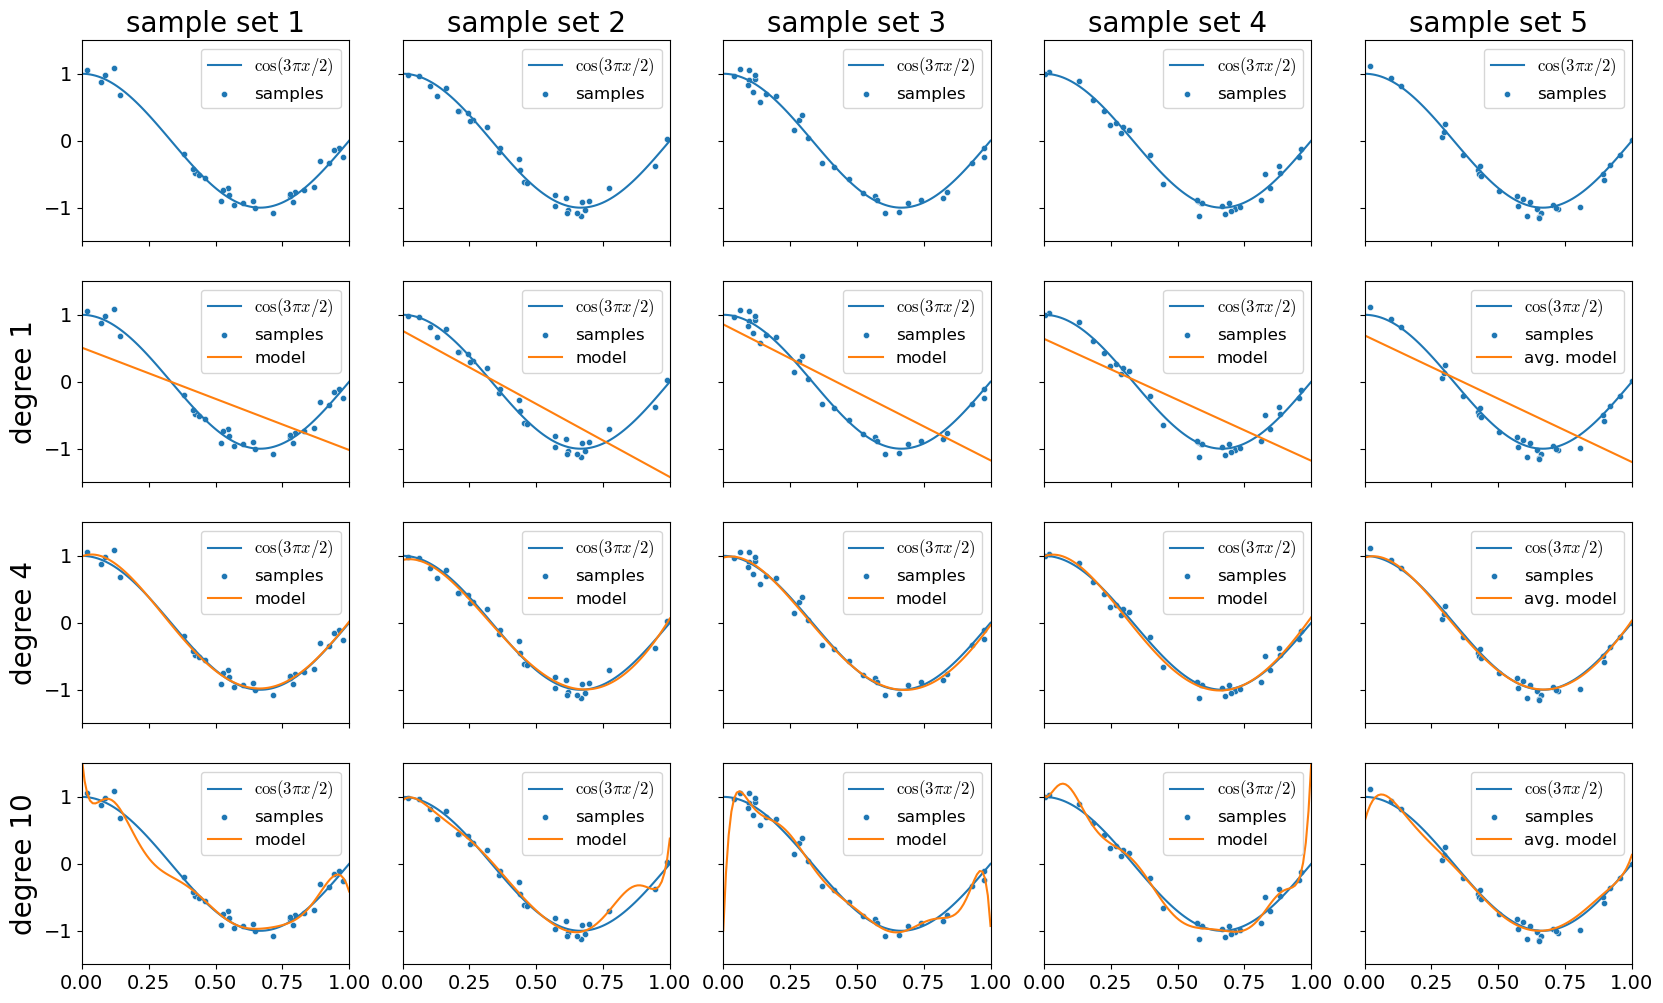

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(0)

trial, n_samples = 5, 30
degrees = [1, 4, 10]
X = np.random.rand(trial, n_samples)
Y = true_fun(X) + np.random.randn(trial, n_samples) * 0.1
X_plot = np.linspace(0, 1, 100)

plt.rcParams.update({
    "mathtext.fontset": 'cm',
    "axes.unicode_minus": True,
})

fig, ax = plt.subplots(len(degrees) + 1, trial, sharex=True, sharey=True, figsize=(20, 12))

# 每个子图画cos函数和样本点
for t in range(trial):
    ax[0, t].set_title(f"sample set {t + 1}")
    x, y = X[t, :], Y[t, :]
    for i in range(len(degrees) + 1):
        sns.lineplot(x=X_plot, y=true_fun(X_plot), label=r"$\cos (3 \pi x  / 2)$", ax=ax[i, t])
        sns.scatterplot(x=x, y=y, s=20, label="samples", ax=ax[i, t])

# 按行来 每行对应一个degree
for i, degree in enumerate(degrees):

    ax[i + 1, 0].set_ylabel(f'degree {degree}')

    polynomial_features = PolynomialFeatures(degree=degree, include_bias=True)
    XX_plot = polynomial_features.fit_transform(X_plot[:, np.newaxis])

    # 前 trial-1 个样本集各训练一个回归模型 最后一个样本集测试平均模型
    lr = [LinearRegression()] * (trial - 1)
    pre_avg = np.zeros(len(X_plot))
    for t in range(trial - 1):
        x, y = X[t, :], Y[t, :]
        lr[t].fit(polynomial_features.fit_transform(x[:, np.newaxis]), y)
        sns.lineplot(x=X_plot, y=lr[t].predict(XX_plot), label="model", ax=ax[i + 1, t])
        pre_avg += lr[t].predict(XX_plot)

    sns.lineplot(x=X_plot, y=pre_avg / 4, label="avg. model", ax=ax[i + 1, -1])

for t in range(trial):
    for i in range(len(degrees) + 1):
        ax[i, t].set(xlim=(0, 1), ylim=(-1.5, 1.5))

plt.show()